# Emuler une ou des parties

Le présent notebook permet de faire s'affronter des joueurs entre eux au cours d'une ou N parties et d'en afficher les statistiques.

## Configuration

In [1]:
#Librairies
import sys
sys.path.append('../onitama/')

from board import Board
from card import Card
from players import Player, RandomPlayer, HeuristicPlayer, LookAheadHeuristicPlayer
from dl_players_v2 import CNNPlayer_v2
from dl_players_v1 import CNNPlayer_v1
from dl_players_v3 import CNNPlayer_v3
from dl_players_v4 import CNNPlayer_v4
from dl_players_v5 import CNNPlayer_v5
from dl_players_v6 import CNNPlayer_v6
from dl_players_v7 import DensePlayer_v7
from dl_players_v9 import DensePlayer_v9
from dl_players_v10 import DensePlayer_v10
from dl_minimax import LookAheadDlPlayer
from alphazero_player import AlphaZeroPlayer
from game import Game, GameSession
import random
import numpy as np
from constants import *
from tqdm import tqdm
import numpy as np
import time
from card import Card

2026-04-15 12:26:37.610117: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-15 12:26:37.610497: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 12:26:37.650042: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 12:26:38.560787: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [2]:

#Définition des joueurs
PLAYERS = {
    'RandomPlayer' : RandomPlayer(),
    'HeuristicPlayerRegular' : HeuristicPlayer(heuristic_function='heuristic_regular'),
    'HeuristicPlayerAgressive' : HeuristicPlayer(heuristic_function='heuristic_aggressive'),
    'HeuristicPlayerDefensive' : HeuristicPlayer(heuristic_function='heuristic_defensive'),
    'HeuristicPlayerMobility' : HeuristicPlayer(heuristic_function='heuristic_mobility'),
    'HeuristicPlayerPositional' : HeuristicPlayer(heuristic_function='heuristic_positional'),
    'LookAhead2PlayerRegular' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_regular'),
    'LookAhead2PlayerAgressive' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_aggressive'),
    'LookAhead2PlayerDefensive' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_defensive'),
    'LookAhead2PlayerMobility' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_mobility'),
    'LookAhead2PlayerPositional' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_positional'),
    'LookAhead3PlayerRegular' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_regular'),
    'LookAhead3PlayerAgressive' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_aggressive'),
    'LookAhead3PlayerDefensive' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_defensive'),
    'LookAhead3PlayerMobility' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_mobility'),
    'LookAhead3PlayerPositional' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_positional'),
    'Musashi1' : CNNPlayer_v4(model_file='../models/compiled/musashi1.keras'),
    'Musashi2' : CNNPlayer_v4(model_file='../models/compiled/musashi2.keras'),
    'Musashi3' : CNNPlayer_v4(model_file='../models/compiled/musashi3.keras'),
    'Kamae2' : CNNPlayer_v6(model_file='../models/compiled/kamae2.keras'),
    'Kamae3' : CNNPlayer_v6(model_file='../models/compiled/kamae3.keras'),
    'Kamae4' : CNNPlayer_v6(model_file='../models/compiled/kamae4.keras'),
    'Kamae5' : CNNPlayer_v6(model_file='../models/compiled/kamae5.keras'),
    'Tairanauchu1' : DensePlayer_v7(model_file='../models/compiled/tairanauchu1.keras'),
    'Tairanauchu2' : DensePlayer_v7(model_file='../models/compiled/tairanauchu2.keras'),
    'Tairanauchu3' : DensePlayer_v7(model_file='../models/compiled/tairanauchu3.keras'),
    'Shigemori1' : DensePlayer_v9(model_file='../models/compiled/shigemori1.keras'),
    'Shigemori2' : DensePlayer_v9(model_file='../models/compiled/shigemori2.keras'),
    'Shigemori3' : DensePlayer_v9(model_file='../models/compiled/shigemori3.keras'),
    'Sukoshi1' : DensePlayer_v10(model_file='../models/compiled/sukoshi1.keras'),
    'Sukoshi2' : DensePlayer_v10(model_file='../models/compiled/sukoshi2.keras'),
    'Sukoshi3' : DensePlayer_v10(model_file='../models/compiled/sukoshi3.keras'),
    'Shingen' : LookAheadDlPlayer(max_depth=5, dl_player=CNNPlayer_v6(model_file='../models/compiled/kamae5.keras'), n_best_moves=3),
    'Nobunaga' : AlphaZeroPlayer(dl_player=CNNPlayer_v6(model_file='../models/compiled/kamae5.keras'), num_simulations=1000)
}

2026-04-15 12:26:40.424578: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Jouer une session de N parties

In [ ]:
player1 = PLAYERS['Kamae5']
player2 = PLAYERS['LookAhead2PlayerRegular']
nombre_parties = 100

gameSession = GameSession(player_one=player1, player_two=player2, number_of_games=nombre_parties)
gameSession.start()
print(gameSession.getStats())

Games  : 100%|██████████| 100/100 [00:30<00:00,  3.30it/s]

{'p1_win': 64, 'p2_win': 36, 'draw': 0, 'p1_avg_time': np.float64(5.747737300000644), 'p2_avg_time': np.float64(19.28679782947942)}


## Jouer une partie (verbose)

In [3]:
player1 = PLAYERS['Kamae5']
player2 = PLAYERS['LookAhead2PlayerRegular']

game = Game(player_one=player1, player_two=player2, verbose=True)
game.playGame()

#####################################################################
# NEW GAME !
# PLAYER X : LookAheadHeuristicPlayer
# PLAYER O : CNNPlayerV6
#####################################################################
**********************************************************************
Current player : X

1 | o o O o o
2 | - - - - -
3 | - - - - -
4 | - - - - -
5 | x x X x x
  | A B C D E

Next player cards: Elephant Monkey 
Neutral card: Crab
Current player cards: 
Dragon
X  -  -  -  X
-  -  O  -  -
-  X  -  X  -
Rooster
-  -  X
X  O  X
X  -  -

**********************************************************************
Current player : O

1 | x x X x -
2 | - - x - -
3 | - - - - -
4 | - - - - -
5 | o o O o o
  | A B C D E

Next player cards: Rooster Crab 
Neutral card: Dragon
Current player cards: 
Elephant
X  -  X
X  O  X
Monkey
X  -  X
-  O  -
X  -  X

**********************************************************************
Current player : X

1 | - o O o o
2 | - o - - -
3 | - - - - -
4 | -

## Arène : faire jouer tous les joueurs les uns contre les autres

In [6]:
nombre_parties = 1
stats = {}

for player1_name in PLAYERS:
    player1 = PLAYERS[player1_name]

    stats[player1_name] = {}
    for player2_name in PLAYERS:
        player2 = PLAYERS[player2_name]
        if player1_name == player2_name:
            continue
        
        print(f"{player1_name} vs {player2_name}")
        gameSession = GameSession(player_one=player1, player_two=player2, number_of_games=nombre_parties)
        gameSession.start()
        gameSessionStats = gameSession.getStats()

        stats[player1_name][player2_name] = int(gameSessionStats['p1_win'])

RandomPlayer vs HeuristicPlayerRegular


Games  : 100%|██████████| 1/1 [00:00<00:00, 764.55it/s]


RandomPlayer vs HeuristicPlayerAgressive


Games  : 100%|██████████| 1/1 [00:00<00:00, 568.80it/s]


RandomPlayer vs HeuristicPlayerDefensive


...

Games  : 100%|██████████| 1/1 [01:21<00:00, 81.19s/it]


Nobunaga vs Sukoshi3


Games  : 100%|██████████| 1/1 [01:09<00:00, 69.27s/it]


Nobunaga vs Shingen


Games  : 100%|██████████| 1/1 [02:14<00:00, 134.07s/it]


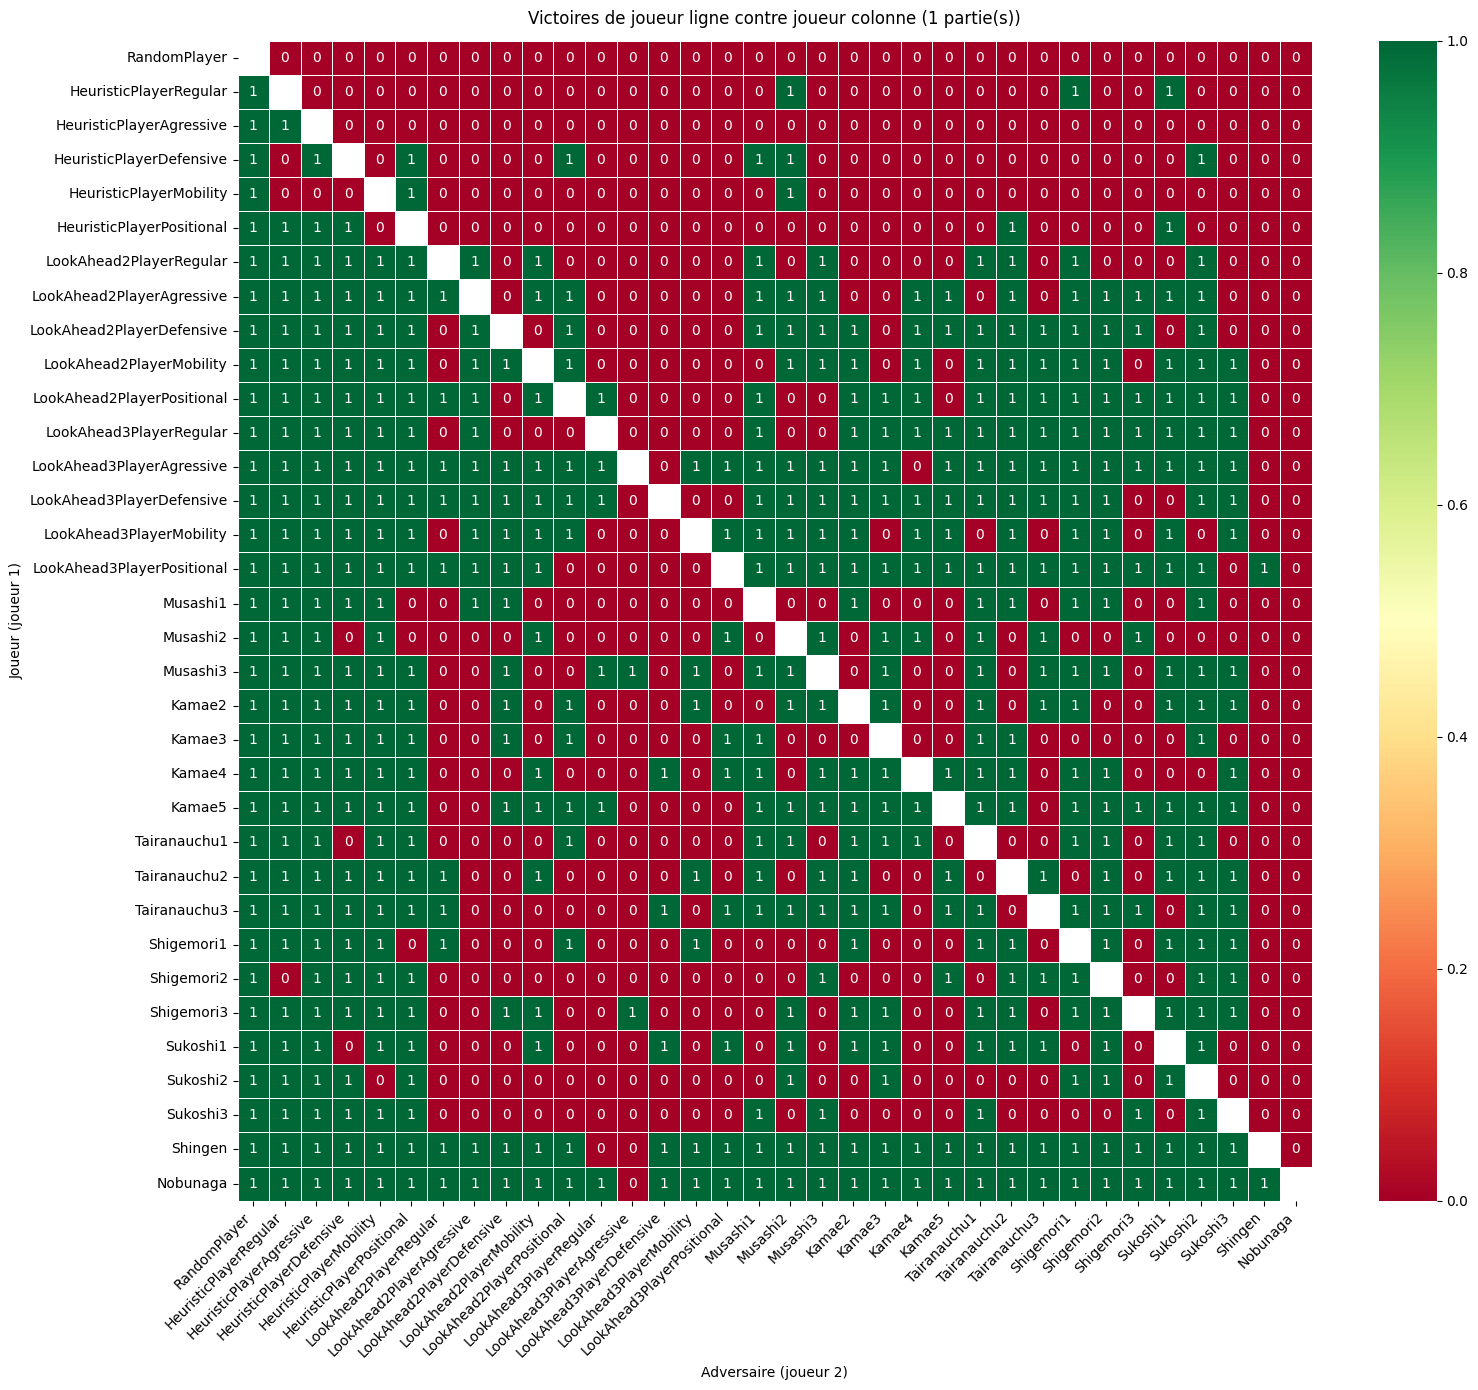

In [ ]:
#Visualisation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

player_names = list(PLAYERS.keys())
matrix = pd.DataFrame(index=player_names, columns=player_names, dtype=float)

for p1 in player_names:
    for p2 in player_names:
        if p1 == p2:
            matrix.loc[p1, p2] = float('nan')
        else:
            matrix.loc[p1, p2] = stats.get(p1, {}).get(p2, float('nan'))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    matrix.astype(float),
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=nombre_parties / 2,
    vmin=0,
    vmax=nombre_parties,
    linewidths=0.5,
    ax=ax,
    xticklabels=True,
    yticklabels=True,
)
ax.set_title(f'Victoires de joueur ligne contre joueur colonne ({nombre_parties} partie(s))', pad=12)
ax.set_xlabel('Adversaire (joueur 2)')
ax.set_ylabel('Joueur (joueur 1)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()